In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [3]:
data = pd.read_csv('/Users/sa12/Documents/Repositories/MusicReccomendation/MusicRecommendation/Data/clean_data.csv')

In [4]:
data = data.drop(columns=('Unnamed: 0'))
cols = data.columns
cols

Index(['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age', 'genre_blues', 'genre_country',
       'genre_hip hop', 'genre_jazz', 'genre_pop', 'genre_reggae',
       'genre_rock'],
      dtype='object')

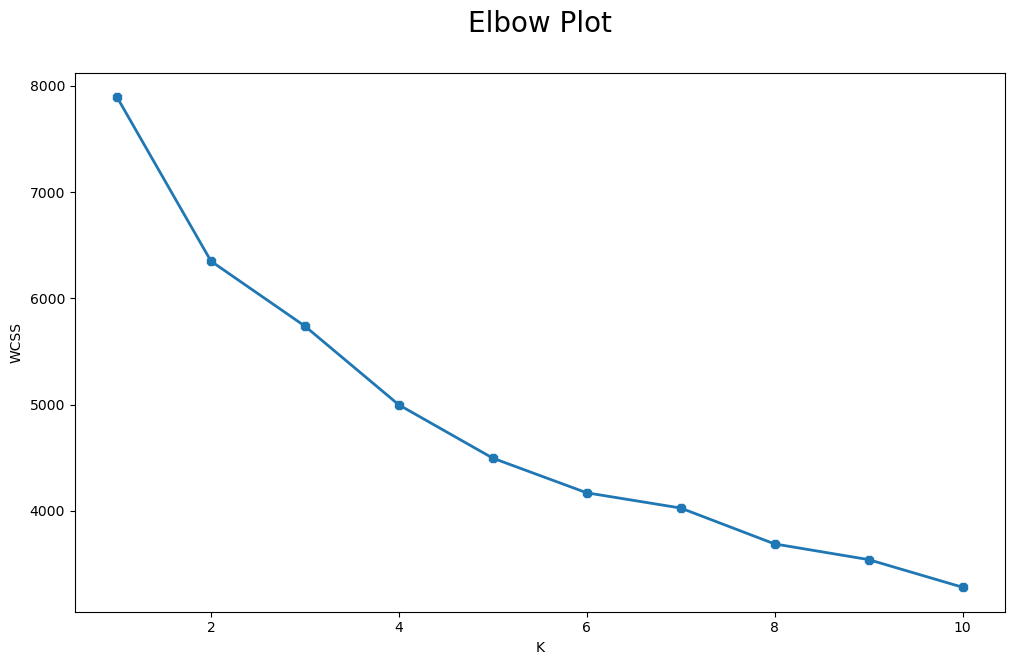

In [5]:
X1 = data.loc[:, ['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music',
       'movement/places', 'light/visual perceptions', 'family/spiritual',
       'sadness', 'feelings', 'age']].values

wcss= []
for k in range(1, 11):
    # TODO: create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`
    # DOCUMENTATION: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (12, 7))

plt.plot(range(1, 11), wcss, linewidth = 2, marker = '8')
plt.title('Elbow Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

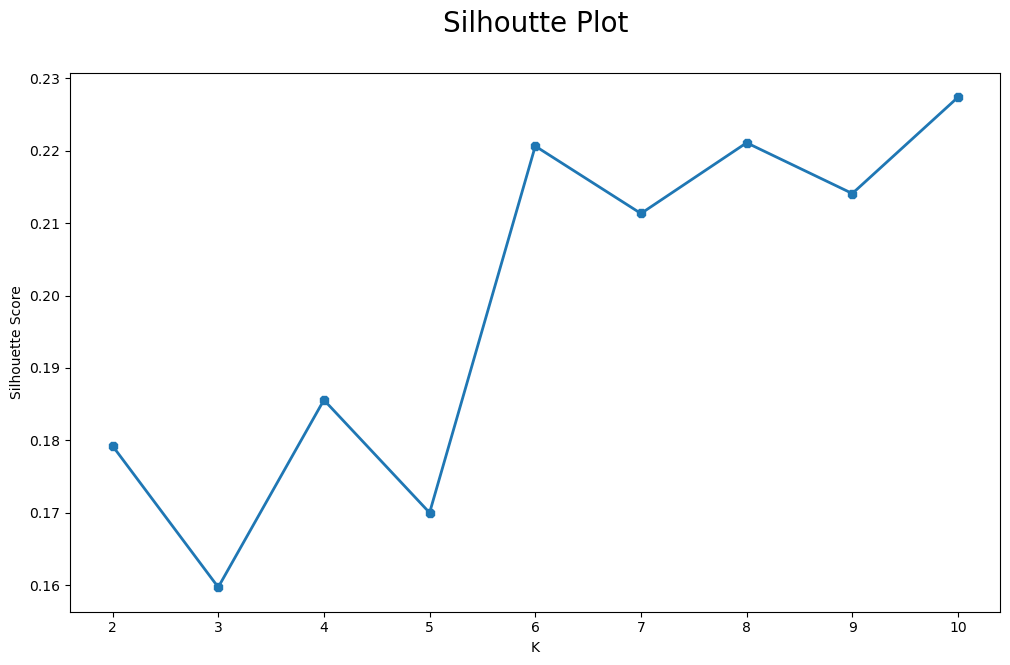

In [6]:
silhouette = []
for k in range(2, 11):
    # TODO: create a Kmeans object initialized with `k` clusters and `init` parameter of `k-means++`
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    predictions = kmeans.fit_predict(X1)
    silhouette.append(metrics.silhouette_score(X1, predictions))

plt.figure(figsize = (12, 7))

plt.plot(range(2, 11), silhouette, linewidth = 2, marker = '8')
plt.title('Silhoutte Plot\n', fontsize = 20)
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.show()

In [7]:
k_means = KMeans(n_clusters=6, init='k-means++')
k_means.fit(X1)

KMeans(n_clusters=6)

In [8]:
# output the centroids of clusters
labels = k_means.fit_predict(X1)
labels
k_means.cluster_centers_

array([[0.01624865, 0.04329674, 0.43573174, 0.03379987, 0.01618676,
        0.01471959, 0.03136522, 0.07469589, 0.02182716, 0.02731431,
        0.04180223, 0.05152237, 0.02826946, 0.05766476, 0.02655486,
        0.37399931],
       [0.02917832, 0.05700932, 0.1000628 , 0.0647163 , 0.01460828,
        0.02250499, 0.09880209, 0.07905455, 0.05196046, 0.10900683,
        0.04511523, 0.05730863, 0.02528099, 0.12523363, 0.04037957,
        0.77393315],
       [0.0197026 , 0.05068919, 0.04116121, 0.027966  , 0.02585552,
        0.01685323, 0.01355335, 0.06686178, 0.46734734, 0.02196488,
        0.06554529, 0.02698895, 0.0162843 , 0.02439222, 0.02000852,
        0.25316418],
       [0.02124458, 0.04182725, 0.05320588, 0.03869051, 0.01474625,
        0.01322081, 0.03480286, 0.08653137, 0.01853653, 0.02820957,
        0.03466391, 0.04657885, 0.01992328, 0.44006619, 0.02415203,
        0.35516956],
       [0.02755119, 0.03359024, 0.03619264, 0.18700776, 0.01842923,
        0.0181452 , 0.08708172, 

In [21]:
clusters = pd.DataFrame(columns=['cluster1','cluster2','cluster3','cluster4','cluster5','cluster6'], index=['dating', 'violence', 'world/life', 'night/time', 'shake the audience',
       'family/gospel', 'romantic', 'communication', 'obscene', 'music','movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age'])
clusters['cluster1'] = k_means.cluster_centers_[0]
clusters['cluster2'] = k_means.cluster_centers_[1]
clusters['cluster3'] = k_means.cluster_centers_[2]
clusters['cluster4'] = k_means.cluster_centers_[3]
clusters['cluster5'] = k_means.cluster_centers_[4]
clusters['cluster6'] = k_means.cluster_centers_[5]
clusters

,cluster1,cluster2,cluster3,cluster4,cluster5,cluster6
dating,0.016249,0.029178,0.019703,0.021245,0.027551,0.012644
violence,0.043297,0.057009,0.050689,0.041827,0.033590,0.437753
world/life,0.435732,0.100063,0.041161,0.053206,0.036193,0.052212
night/time,0.033800,0.064716,0.027966,0.038691,0.187008,0.034017
shake the audience,0.016187,0.014608,0.025856,0.014746,0.018429,0.016789
family/gospel,0.014720,0.022505,0.016853,0.013221,0.018145,0.015419
romantic,0.031365,0.098802,0.013553,0.034803,0.087082,0.021572
communication,0.074696,0.079055,0.066862,0.086531,0.080763,0.071937
obscene,0.021827,0.051960,0.467347,0.018537,0.022894,0.026313
music,0.027314,0.109007,0.021965,0.028210,0.171525,0.023878


This is the meat of our model. These are the most representitive samples of each cluster. By determining 